### `compare_to_reference_algs.ipynb` 
*Created: Oct 6, 2026* <br/>
In this notebook we write a function for testing a custom ODE solver against some trusted reference algorithms. 

In [1]:
using OrdinaryDiffEq
using OrdinaryDiffEqExponentialRK, SciMLOperators
import SciMLBase: solve

using Printf, Test, LinearAlgebra, Statistics
using NBInclude, UnPack
using CairoMakie, LaTeXStrings

In [2]:
@nbinclude("etd_rk43.ipynb")
@nbinclude("etd_test_problems.ipynb")

In [53]:
function compare_algs(custom_alg, reference_alg, prob::ODEProblem; abstol = 1e-6, reltol = 1e-3, dt = 0.01, maxiters = 10_000)
   
    #Solution using custom algorithm (the one whose accuracy and performance we are testing) 
    #sol_custom = solve(prob, custom_alg; abstol = abstol, reltol = reltol, dt = dt, maxiters = maxiters)
    sol_custom = solve(prob, custom_alg; abstol = 1e-9, reltol = 1e-6, dt = dt, maxiters = maxiters)

    #Solution using reference algorithm (the one we trust!) 
    #sol_reference = solve(prob, reference_alg; abstol = abstol, reltol = reltol, dt = dt, maxiters = maxiters, saveat = sol_custom.t, save_end = true)

     sol_reference = solve(prob, reference_alg; abstol = abstol, reltol = reltol, dt = 0.005, maxiters = 100_000, saveat = sol_custom.t, save_end = true)
    
    sol_reference.retcode == ReturnCode.Success || error("Reference solver failed; sol_reference.retcode = $(sol_reference.retcode)")
        
    #Add check that both algorithms succeeded before computing an error norm 
    u_reference = sol_reference.u
    u_custom = sol_custom.u

    t_reference = sol_reference.t
    t_custom = sol_custom.t

    min_length = min(length(t_reference), length(t_custom))
    idx_stop = findfirst(i -> abs(t_reference[i] - t_custom[i]) ≥ 1e-20, 1:min_length)
    println("\nabs(t_reference[$(idx_stop)] - t_custom[$(idx_stop)]) = $(abs(t_reference[idx_stop] - t_custom[idx_stop]))")

    u_ref = u_reference[1:idx_stop-1]
    u_cus = u_custom[1:idx_stop-1]
 
    errors = u_ref .- u_cus

    abs_errors = norm.(errors, Inf)
    rel_errors = abs_errors ./ norm.(u_ref, Inf)


    @show mean(abs_errors)
    @show mean(rel_errors)
    
    return (sol_reference = sol_reference, sol_custom = sol_custom, abs_errors = abs_errors, rel_errors = rel_errors)
end 

compare_algs (generic function with 1 method)

In [64]:
#out = compare_algs(ETDRK43(), ETDRK4(), vanderpol_prob; maxiters = 10_000, dt = 0.01);
#out = compare_algs(ETDRK43(), ETDRK4(), rotation_prob; maxiters = 10_000, dt = 0.01);
out = compare_algs(ETDRK43(), ETDRK4(), riccati_prob; maxiters = 10_000, dt = 0.01);

LoadError: type ScalarOperator has no field A

In [57]:
#Test 1: Van der Pol oscillator
p = 10.0
A_vdp = [0.0 1.0; -1.0 p] 
vdp_nonlin(u,p,t) = [0.0, -p*(u[1])^2 * u[2]]
u0 = [2.0, 0.0]
tspan = (0.0, 50.0)

vanderpol = SplitODEProblem(MatrixOperator(A_vdp), vdp_nonlin, u0, tspan, p);
@time sol_custom = solve(vanderpol, ETDRK43(); abstol = 1e-9, reltol = 1e-6, dt = 0.005, maxiters = 100_000)
@time sol_ref = solve(vanderpol, ETDRK4(); abstol = 1e-9, reltol = 1e-6, maxiters = 100_000, dt = 0.001, saveat = sol_custom.t, save_end = true);

Starting integration loop...
Step acceptance rate: 91.72 %  1.144900 seconds (1.50 M allocations: 103.231 MiB, 1.85% gc time, 92.93% compilation time: 100% of which was recompilation)
  0.851159 seconds (3.79 M allocations: 155.070 MiB, 1.74% gc time, 92.19% compilation time: 100% of which was recompilation)


In [58]:
@unpack sol_custom, sol_reference = out
u_custom = sol_custom.u
t_custom = sol_custom.t

u_reference = sol_reference.u
t_reference = sol_reference.t

min_length = min(length(t_custom), length(t_reference)) 
idx_stop = findfirst(i -> abs(t_reference[i] - t_custom[i]) ≥ 1e-20, 1:min_length)

u_cus = u_custom[1:idx_stop-1]
t_cus = t_custom[1:idx_stop-1]

u_ref = u_reference[1:idx_stop-1];
t_ref = t_reference[1:idx_stop-1];

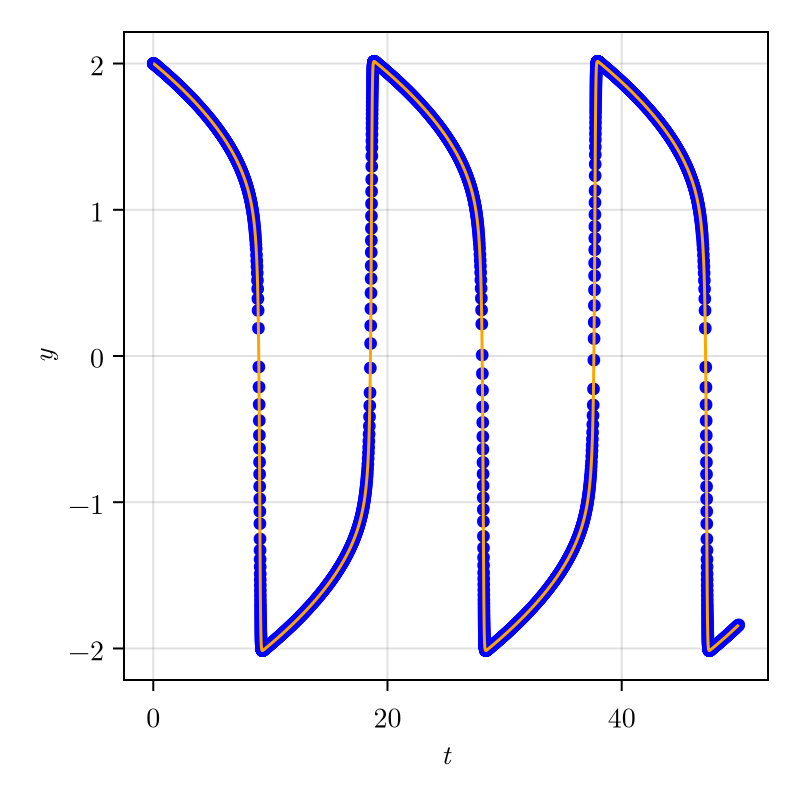

CairoMakie.Screen{IMAGE}


In [63]:
fig = Figure(size = (400,400))
ax = Axis(fig[1,1], xlabel = L"t", ylabel = L"y")

scatter!(ax, t_cus, getindex.(u_cus, 1), color = :blue, label = "ETDRK4(3)")
lines!(ax, t_ref, getindex.(u_ref, 1), color = :orange, label = "ETDRK4")
#axislegend(ax, :topright)
display(fig)

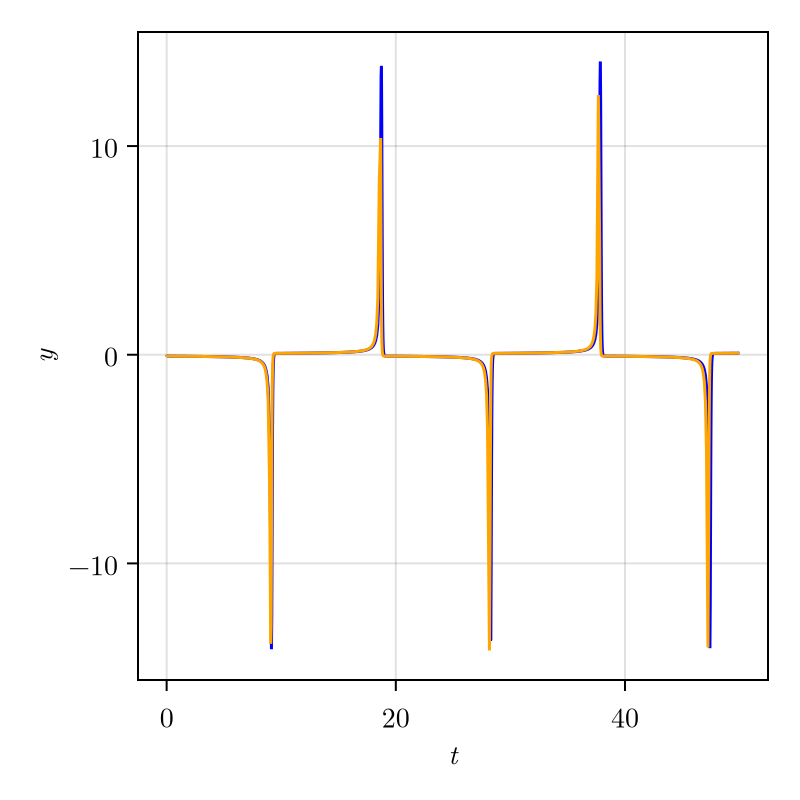

CairoMakie.Screen{IMAGE}


In [49]:
fig = Figure(size = (400,400))
ax = Axis(fig[1,1], xlabel = L"t", ylabel = L"y")

lines!(ax, t_cus, getindex.(u_cus, 2), color = :blue, label = "ETDRK4(3)")
lines!(ax, t_ref, getindex.(u_ref, 2), color = :orange, label = "ETDRK4")
#axislegend(ax, :topright)
display(fig)

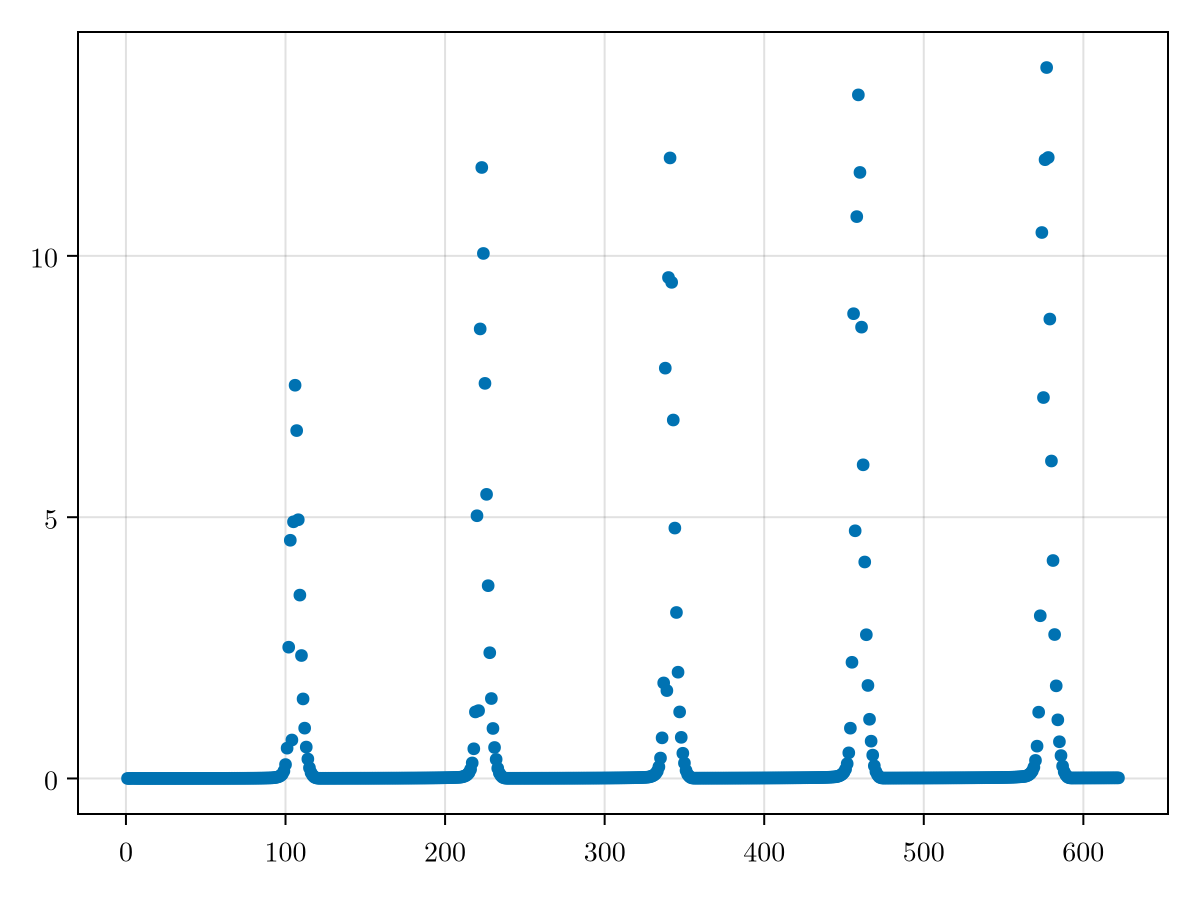

In [48]:
scatter(out.abs_errors)